# Eksperimen Preprocessing — Adult Income Dataset

**Student :** Timotius Kristafael Harjanto  
**Course   :** Sistem Machine Learning Production (SMSML) — Dicoding  
**Dataset  :** Adult Income (Census Income) — UCI ML Repository  
**Task     :** Binary Classification — predict whether income > $50K  

---

## Pipeline Overview

1. Data Loading
2. Data Inspection
3. Missing Value Analysis
4. Duplicate Analysis
5. Outlier Analysis
6. Exploratory Data Analysis (EDA)
7. Feature Engineering
8. Encoding
9. Scaling
10. Train/Test Split & Save

In [1]:
# ─── Imports ─────────────────────────────────────────────────────────────
import os
import warnings
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})
sns.set_theme(style='whitegrid', palette='husl')

print('Libraries loaded successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries loaded successfully!
NumPy  : 1.26.4
Pandas : 2.2.3


## 1. Data Loading

The **Adult Income** dataset is sourced from the UCI ML Repository.
It contains 48,842 rows and 14 features describing US census respondents.
The binary target variable `income` indicates whether annual income exceeds $50K.

In [2]:
# Column names (the raw file has no header row)
COLUMN_NAMES = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

RAW_URL  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
RAW_PATH = '../dataset_raw/adult.csv'

os.makedirs('../dataset_raw', exist_ok=True)

if not os.path.exists(RAW_PATH):
    print(f'Downloading dataset from UCI…')
    urllib.request.urlretrieve(RAW_URL, RAW_PATH)
    print(f'Saved to {RAW_PATH}')
else:
    print(f'Using cached file: {RAW_PATH}')

df_raw = pd.read_csv(
    RAW_PATH, names=COLUMN_NAMES,
    sep=',', skipinitialspace=True, na_values='?'
)

print(f'\nDataset shape : {df_raw.shape}')
print(f'Columns       : {df_raw.columns.tolist()}')
df_raw.head()

Using cached file: ../dataset_raw/adult.csv

Dataset shape : (32561, 15)
Columns       : ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. Data Inspection

In [3]:
print('=== Dataset Info ===')
df_raw.info()
print()
print('=== Data Types ===')
print(df_raw.dtypes)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

=== Data Types ===
age                int64
workclass         object
fn

In [4]:
print('=== Statistical Summary (Numerical) ===')
df_raw.describe()

=== Statistical Summary (Numerical) ===


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
print('=== Categorical Column Value Counts ===')
cat_cols = ['workclass', 'education', 'marital_status', 'occupation',
            'relationship', 'race', 'sex', 'income']
for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df_raw[col].value_counts())

=== Categorical Column Value Counts ===

--- workclass ---
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

--- education ---
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

--- marital_status ---
marital_status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

--- occ

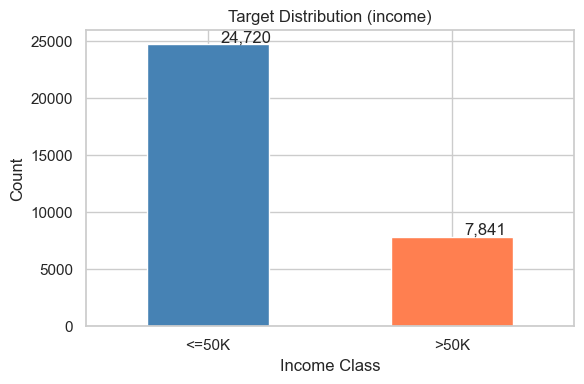

In [6]:
# Target class distribution
fig, ax = plt.subplots(figsize=(6, 4))
df_raw['income'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Target Distribution (income)')
ax.set_xlabel('Income Class')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+0.3, p.get_height()+200))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Missing Value Analysis

In [7]:
# Count missing values per column
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False)

print('=== Missing Value Summary ===')
print(missing_df)
print(f'\nTotal missing values: {df_raw.isnull().sum().sum()}')

=== Missing Value Summary ===
                Count  Percentage (%)
occupation       1843            5.66
workclass        1836            5.64
native_country    583            1.79

Total missing values: 4262


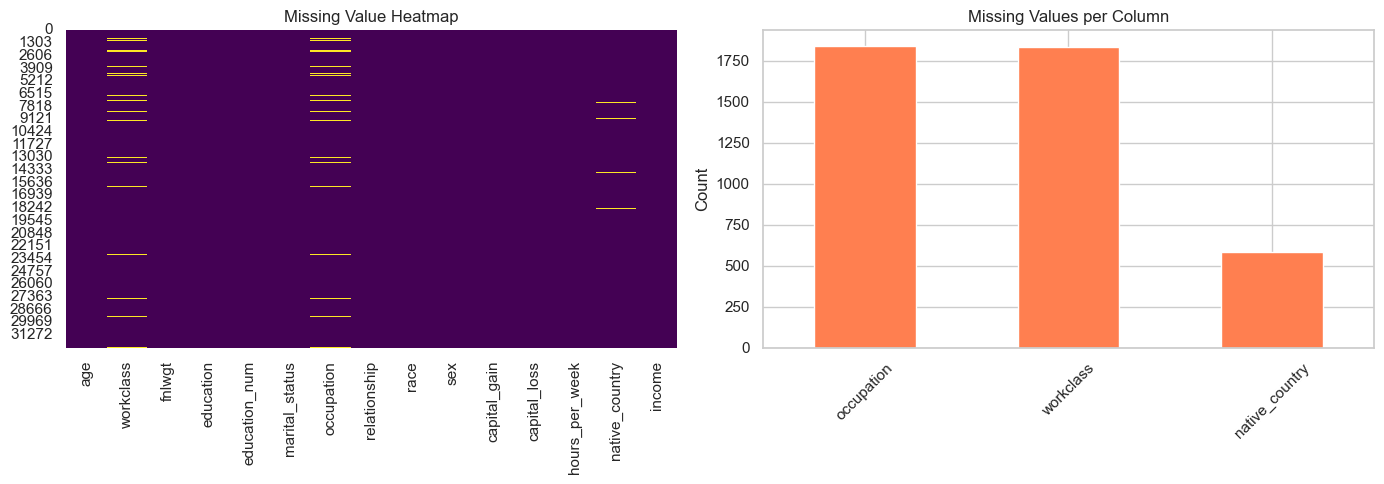

In [8]:
# Heatmap of missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: heatmap
sns.heatmap(df_raw.isnull(), cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Value Heatmap')

# Right: bar chart of missing counts
if not missing_df.empty:
    missing_df['Count'].plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title('Missing Values per Column')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].text(0.5, 0.5, 'No missing values detected!', ha='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

In [9]:
# Strategy: drop rows with missing values (only ~2% of data)
df = df_raw.dropna().reset_index(drop=True)
print(f'Rows before: {len(df_raw):,}')
print(f'Rows after:  {len(df):,}')
print(f'Removed:     {len(df_raw) - len(df):,} ({(len(df_raw)-len(df))/len(df_raw)*100:.2f}%)')

Rows before: 32,561
Rows after:  30,162
Removed:     2,399 (7.37%)


## 4. Duplicate Analysis

In [10]:
n_dup = df.duplicated().sum()
print(f'Number of duplicate rows: {n_dup}')

if n_dup > 0:
    print('\nSample duplicates:')
    print(df[df.duplicated(keep=False)].head(4))
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Dataset shape after removing duplicates: {df.shape}')
else:
    print('No duplicates found — dataset is clean.')

Number of duplicate rows: 23

Sample duplicates:
      age workclass  fnlwgt     education  education_num marital_status  \
2121   90   Private   52386  Some-college             10  Never-married   
3594   19   Private  251579  Some-college             10  Never-married   
3964   25   Private  308144     Bachelors             13  Never-married   
4364   21   Private  250051  Some-college             10  Never-married   

          occupation   relationship                race     sex  capital_gain  \
2121   Other-service  Not-in-family  Asian-Pac-Islander    Male             0   
3594   Other-service      Own-child               White    Male             0   
3964    Craft-repair  Not-in-family               White    Male             0   
4364  Prof-specialty      Own-child               White  Female             0   

      capital_loss  hours_per_week native_country income  
2121             0              35  United-States  <=50K  
3594             0              14  United-States  

## 5. Outlier Analysis

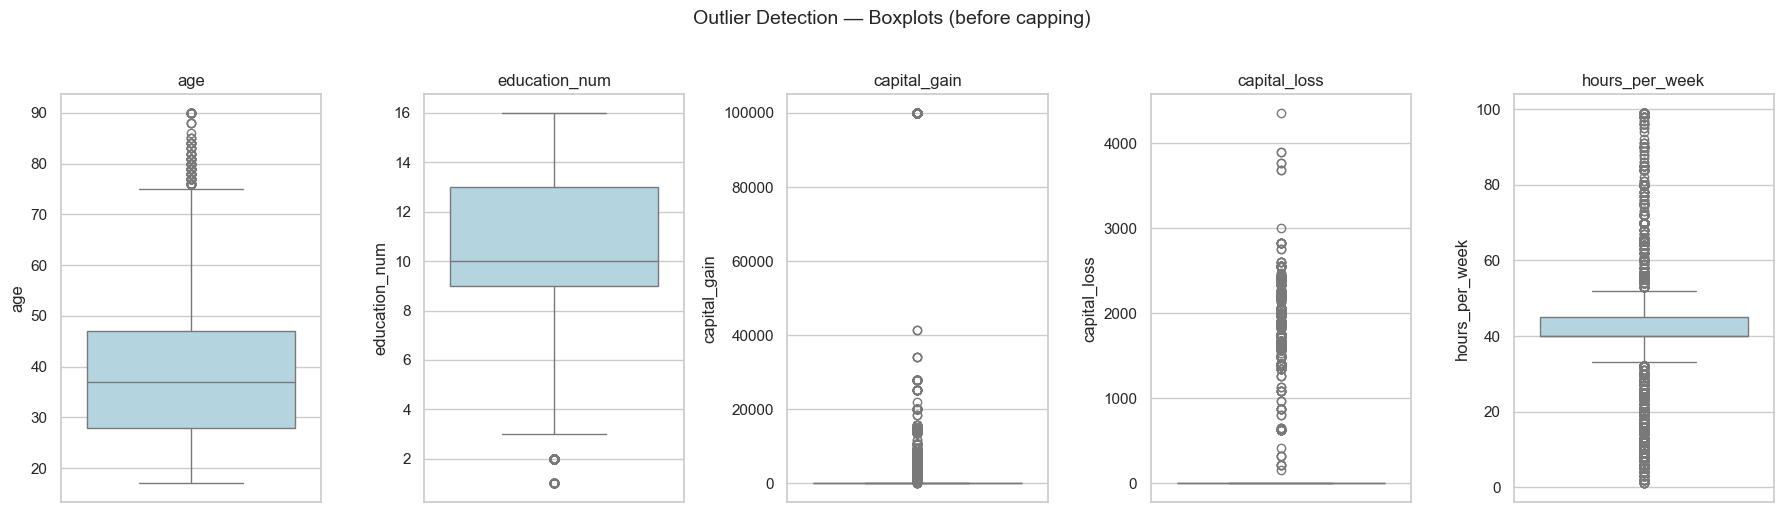

In [11]:
NUMERICAL_COLS = ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

# Box plots before capping
fig, axes = plt.subplots(1, len(NUMERICAL_COLS), figsize=(18, 5))
for ax, col in zip(axes, NUMERICAL_COLS):
    sns.boxplot(y=df[col], ax=ax, color='lightblue')
    ax.set_title(col)
fig.suptitle('Outlier Detection — Boxplots (before capping)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# IQR Outlier Summary
print('=== Outlier Summary (3×IQR rule) ===')
for col in NUMERICAL_COLS:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 3 * IQR
    hi  = Q3 + 3 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'{col:20s}: Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}  bounds=[{lo:.1f}, {hi:.1f}]  outliers={n_out}')

=== Outlier Summary (3×IQR rule) ===
age                 : Q1=28.0  Q3=47.0  IQR=19.0  bounds=[-29.0, 104.0]  outliers=0
education_num       : Q1=9.0  Q3=13.0  IQR=4.0  bounds=[-3.0, 25.0]  outliers=0
capital_gain        : Q1=0.0  Q3=0.0  IQR=0.0  bounds=[0.0, 0.0]  outliers=2538
capital_loss        : Q1=0.0  Q3=0.0  IQR=0.0  bounds=[0.0, 0.0]  outliers=1427
hours_per_week      : Q1=40.0  Q3=45.0  IQR=5.0  bounds=[25.0, 60.0]  outliers=3735


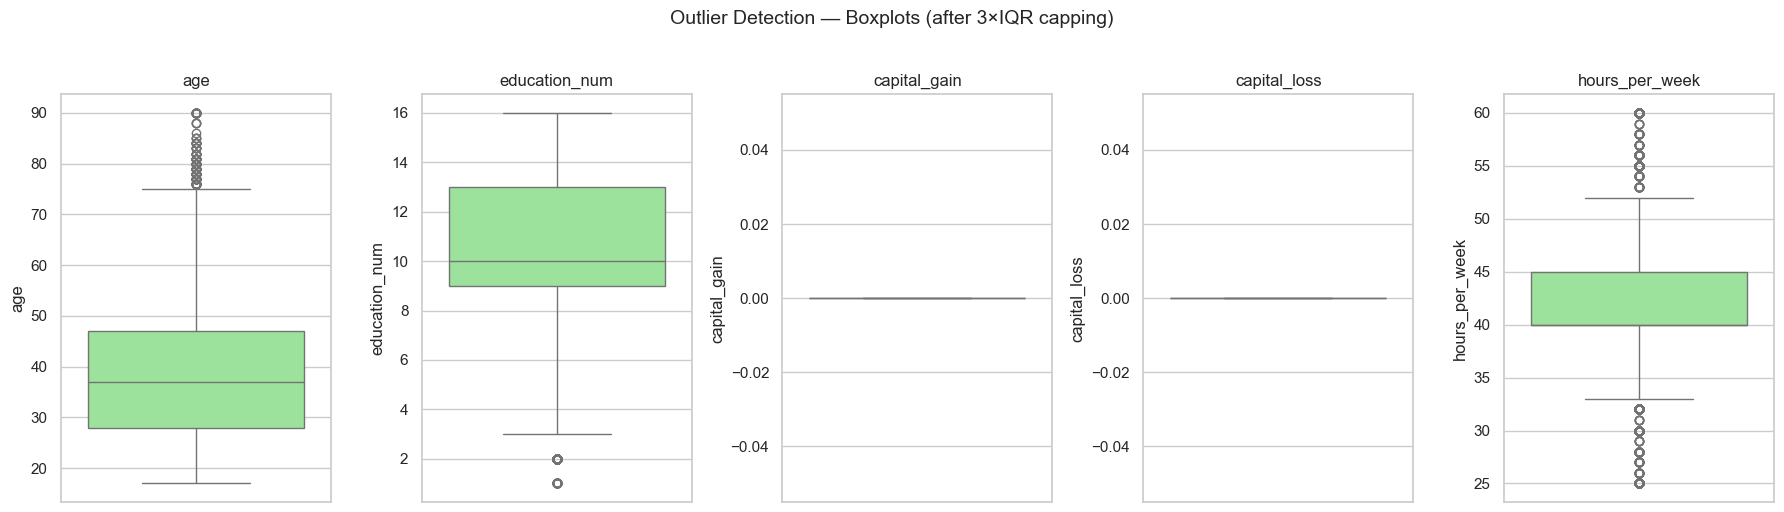

In [13]:
# Cap outliers
df_clean = df.copy()
for col in NUMERICAL_COLS:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean[col] = df_clean[col].clip(lower=Q1 - 3*IQR, upper=Q3 + 3*IQR)

# Box plots after capping
fig, axes = plt.subplots(1, len(NUMERICAL_COLS), figsize=(18, 5))
for ax, col in zip(axes, NUMERICAL_COLS):
    sns.boxplot(y=df_clean[col], ax=ax, color='lightgreen')
    ax.set_title(col)
fig.suptitle('Outlier Detection — Boxplots (after 3×IQR capping)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

df = df_clean

## 6. Exploratory Data Analysis (EDA)

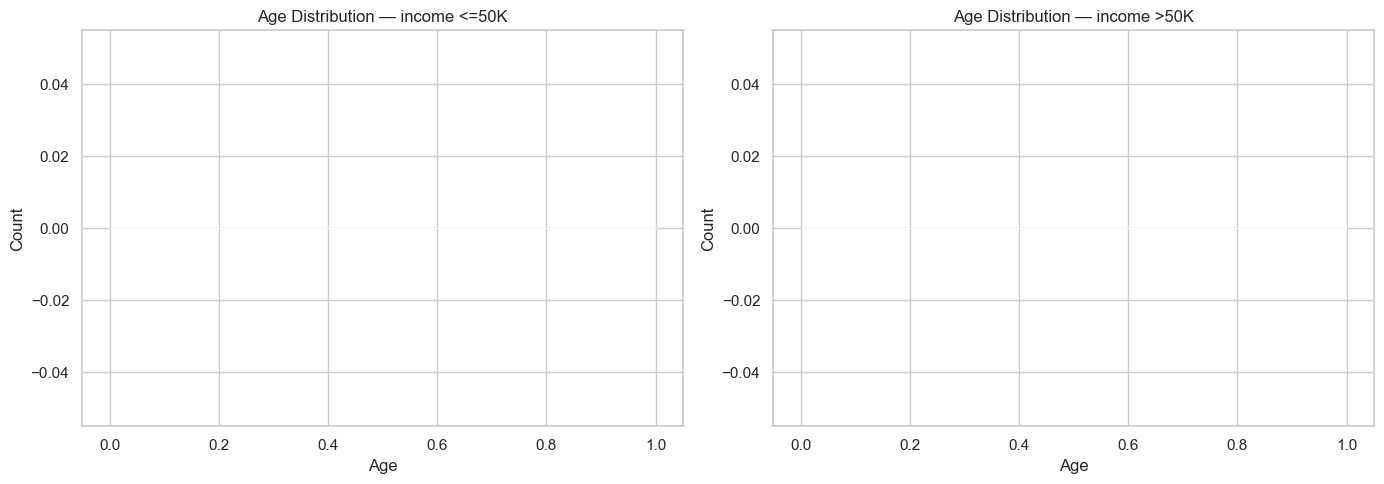

In [14]:
# Age distribution by income class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for income_class, ax in zip([' <=50K', ' >50K'], axes):
    subset = df[df['income'] == income_class]
    ax.hist(subset['age'], bins=30, color='steelblue' if '<=50K' in income_class else 'coral', edgecolor='white')
    ax.set_title(f'Age Distribution — income {income_class.strip()}')
    ax.set_xlabel('Age')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

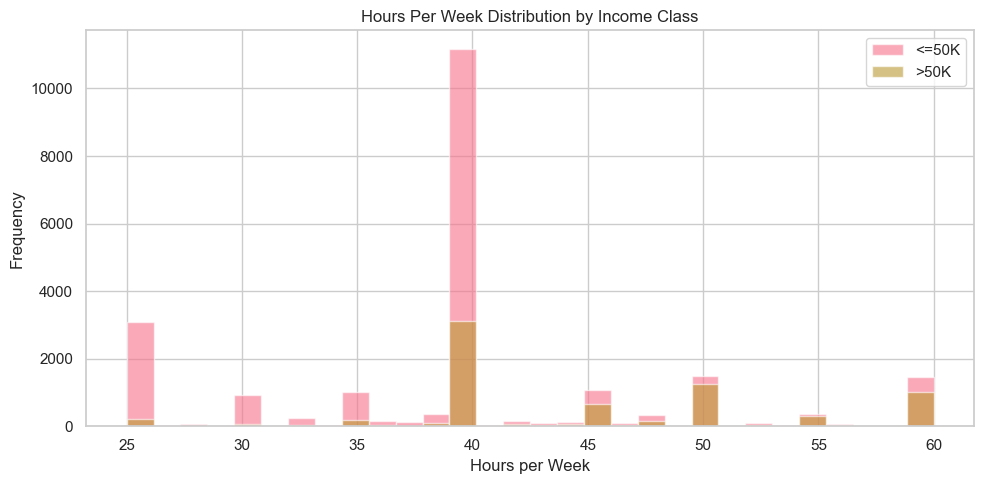

In [15]:
# Hours per week vs. income
fig, ax = plt.subplots(figsize=(10, 5))
df.groupby('income')['hours_per_week'].plot(kind='hist', bins=30, alpha=0.6, ax=ax, legend=True)
ax.set_title('Hours Per Week Distribution by Income Class')
ax.set_xlabel('Hours per Week')
plt.tight_layout()
plt.show()

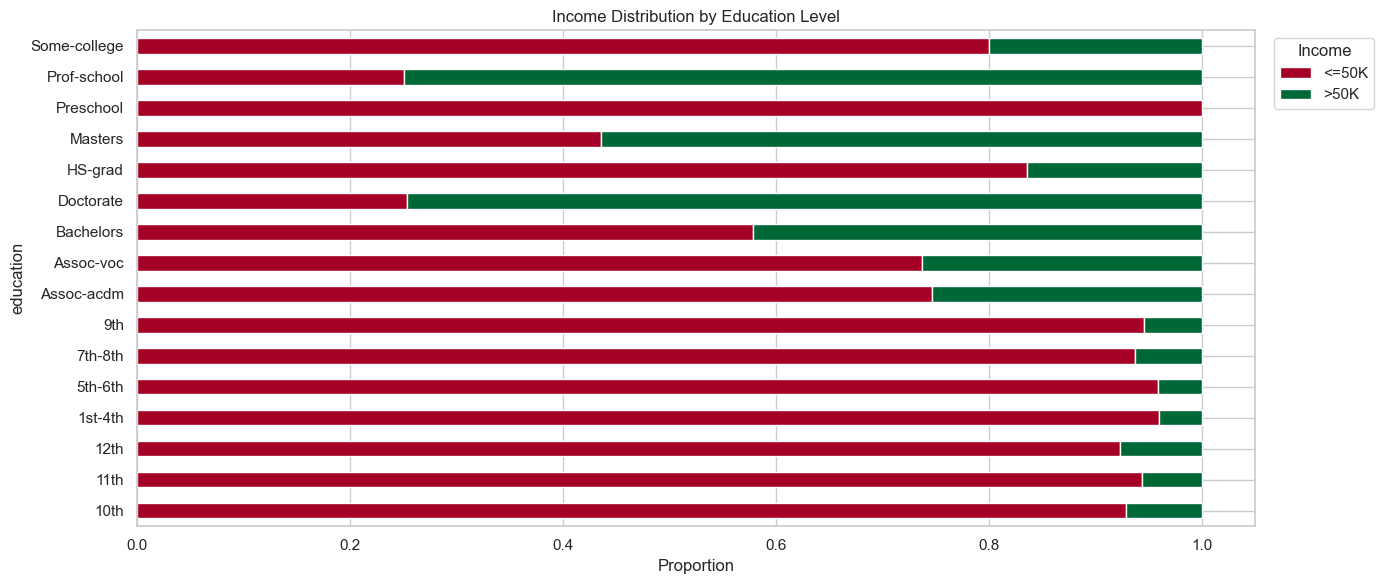

In [16]:
# Education level vs income (stacked bar)
edu_income = df.groupby(['education', 'income']).size().unstack(fill_value=0)
edu_income_pct = edu_income.div(edu_income.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
edu_income_pct.plot(kind='barh', stacked=True, ax=ax, colormap='RdYlGn')
ax.set_title('Income Distribution by Education Level')
ax.set_xlabel('Proportion')
ax.legend(title='Income', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

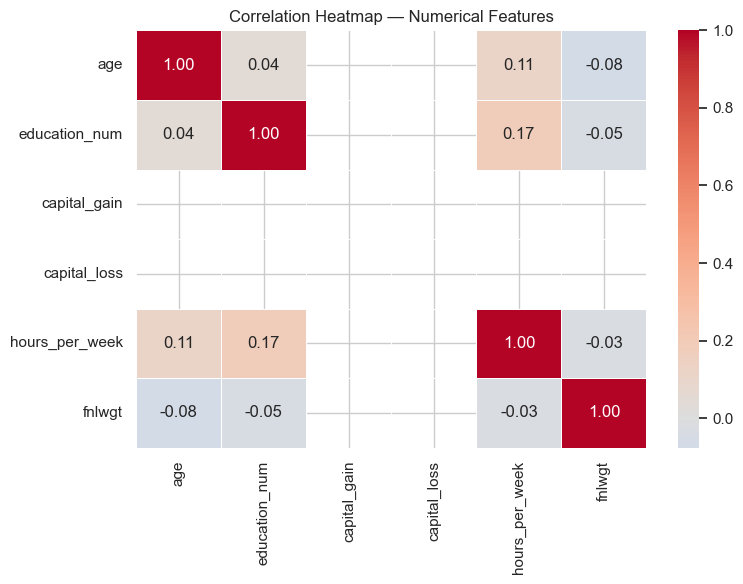

In [17]:
# Correlation heatmap (numerical only)
num_df = df[NUMERICAL_COLS + ['fnlwgt']]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    num_df.corr(), annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=ax, linewidths=0.5
)
ax.set_title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

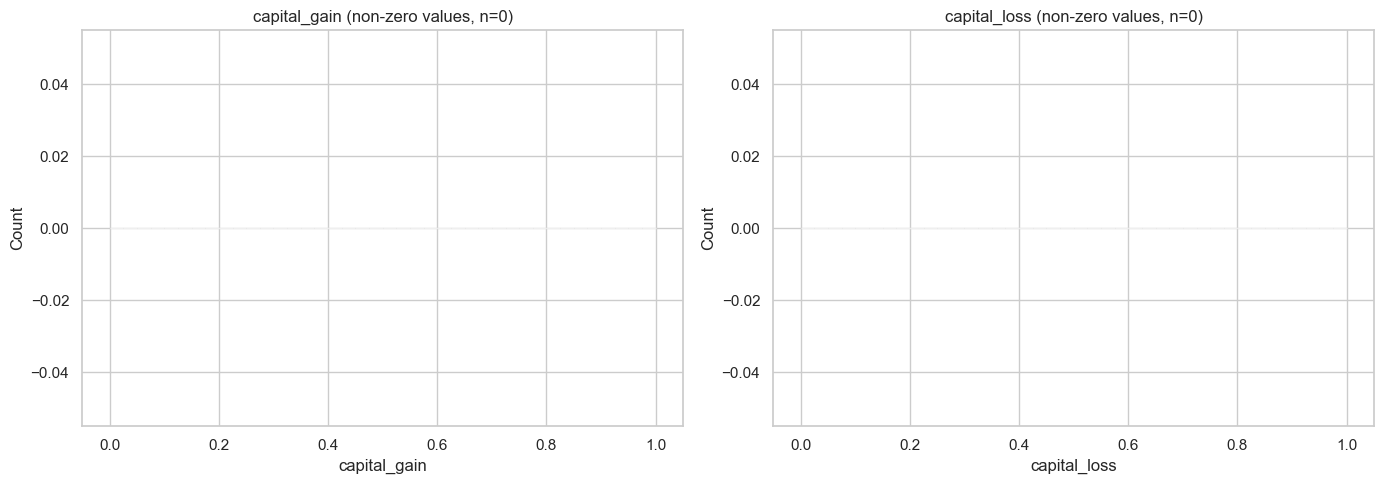

Rows with capital_gain > 0 : 0 (0.0%)
Rows with capital_loss > 0 : 0 (0.0%)


In [18]:
# Capital gain / loss distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for col, ax in zip(['capital_gain', 'capital_loss'], axes):
    nonzero = df[df[col] > 0][col]
    ax.hist(nonzero, bins=40, color='purple', alpha=0.7, edgecolor='white')
    ax.set_title(f'{col} (non-zero values, n={len(nonzero):,})')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(f'Rows with capital_gain > 0 : {(df["capital_gain"]>0).sum():,} ({(df["capital_gain"]>0).mean()*100:.1f}%)')
print(f'Rows with capital_loss > 0 : {(df["capital_loss"]>0).sum():,} ({(df["capital_loss"]>0).mean()*100:.1f}%)')

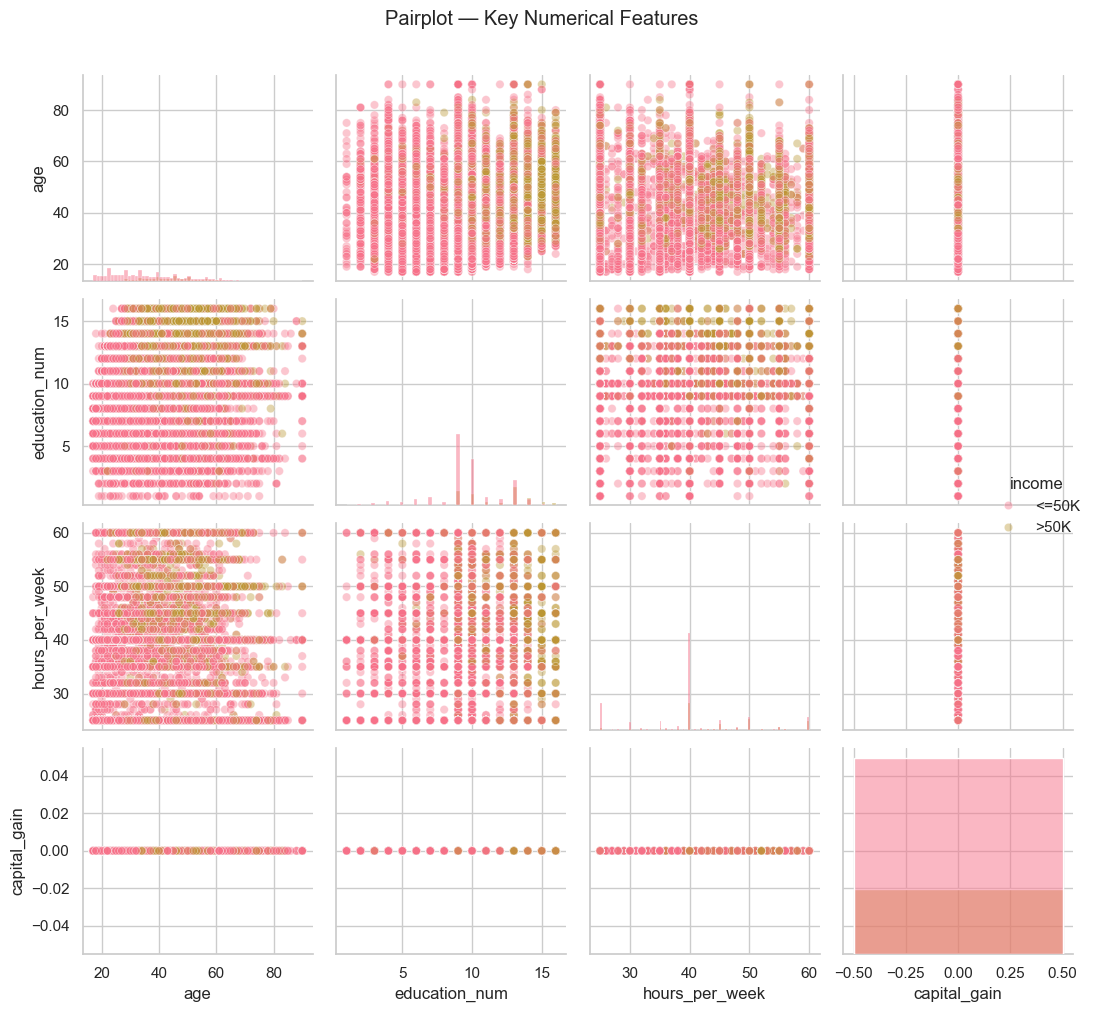

In [19]:
# Pairplot (subset of columns)
pairplot_cols = ['age', 'education_num', 'hours_per_week', 'capital_gain', 'income']
pp_df = df[pairplot_cols].copy()
pp_df['income'] = pp_df['income'].str.strip()
sns.pairplot(pp_df, hue='income', plot_kws={'alpha': 0.4}, diag_kind='hist')
plt.suptitle('Pairplot — Key Numerical Features', y=1.01)
plt.tight_layout()
plt.show()

## 7. Feature Engineering

Creating 7 new features to improve model performance:
1. `age_group` — categorical age bucket
2. `capital_net` — net capital (gain − loss)
3. `has_capital_gain` — binary flag
4. `has_capital_loss` — binary flag
5. `higher_education` — college-or-above flag
6. `work_hours_category` — hours bucket
7. `is_married` — marital status flag

In [20]:
df_eng = df.copy()

# 1. Age bucket
df_eng['age_group'] = pd.cut(
    df_eng['age'],
    bins=[0, 25, 35, 50, 65, 100],
    labels=['Young', 'YoungAdult', 'MiddleAge', 'Senior', 'Elderly']
)

# 2. Capital net
df_eng['capital_net'] = df_eng['capital_gain'] - df_eng['capital_loss']

# 3 & 4. Capital flags
df_eng['has_capital_gain'] = (df_eng['capital_gain'] > 0).astype(int)
df_eng['has_capital_loss'] = (df_eng['capital_loss'] > 0).astype(int)

# 5. Higher education
higher_ed = {'Bachelors', 'Some-college', 'Masters', 'Doctorate', 'Prof-school'}
df_eng['higher_education'] = df_eng['education'].isin(higher_ed).astype(int)

# 6. Work hours category
df_eng['work_hours_category'] = pd.cut(
    df_eng['hours_per_week'],
    bins=[0, 35, 40, 50, 168],
    labels=['PartTime', 'FullTime', 'Overtime', 'Heavy']
)

# 7. Married flag
married_statuses = {'Married-civ-spouse', 'Married-AF-spouse'}
df_eng['is_married'] = df_eng['marital_status'].isin(married_statuses).astype(int)

print(f'Shape after feature engineering: {df_eng.shape}')
print(f'New columns: {[c for c in df_eng.columns if c not in df.columns]}')
df_eng.head()

Shape after feature engineering: (30139, 22)
New columns: ['age_group', 'capital_net', 'has_capital_gain', 'has_capital_loss', 'higher_education', 'work_hours_category', 'is_married']


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,...,hours_per_week,native_country,income,age_group,capital_net,has_capital_gain,has_capital_loss,higher_education,work_hours_category,is_married
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,...,40,United-States,<=50K,MiddleAge,0,0,0,1,FullTime,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,...,25,United-States,<=50K,MiddleAge,0,0,0,1,PartTime,1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,...,40,United-States,<=50K,MiddleAge,0,0,0,0,FullTime,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,...,40,United-States,<=50K,Senior,0,0,0,0,FullTime,1
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,...,40,Cuba,<=50K,YoungAdult,0,0,0,1,FullTime,1


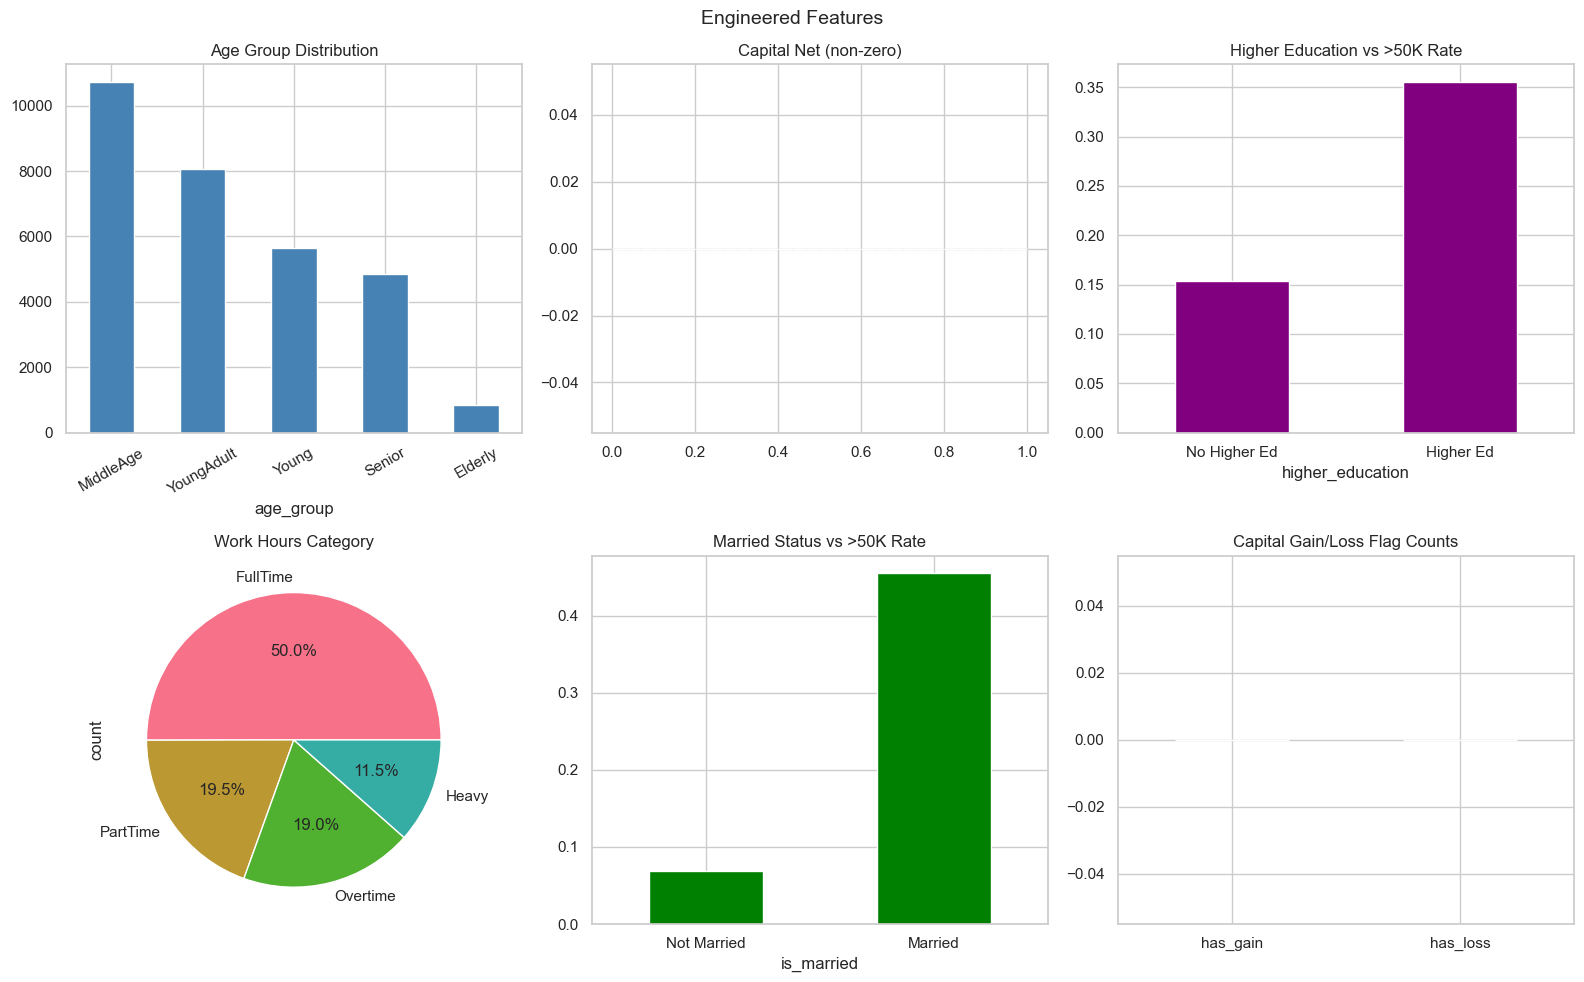

In [21]:
# Visualise engineered features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Age group distribution
df_eng['age_group'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Age Group Distribution')
axes[0,0].tick_params(axis='x', rotation=30)

# Capital net distribution
nonzero_net = df_eng[df_eng['capital_net'] != 0]['capital_net']
axes[0,1].hist(nonzero_net, bins=30, color='coral', edgecolor='white')
axes[0,1].set_title('Capital Net (non-zero)')

# Higher education vs income
df_eng.groupby('higher_education')['income'].apply(
    lambda x: (x.str.strip() == '>50K').mean()
).plot(kind='bar', ax=axes[0,2], color='purple')
axes[0,2].set_title('Higher Education vs >50K Rate')
axes[0,2].set_xticklabels(['No Higher Ed', 'Higher Ed'], rotation=0)

# Work hours category
df_eng['work_hours_category'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%')
axes[1,0].set_title('Work Hours Category')

# Is married vs income
df_eng.groupby('is_married')['income'].apply(
    lambda x: (x.str.strip() == '>50K').mean()
).plot(kind='bar', ax=axes[1,1], color='green')
axes[1,1].set_title('Married Status vs >50K Rate')
axes[1,1].set_xticklabels(['Not Married', 'Married'], rotation=0)

# Capital flags
flag_data = pd.DataFrame({
    'has_gain': df_eng['has_capital_gain'].sum(),
    'has_loss': df_eng['has_capital_loss'].sum()
}, index=[0])
flag_data.T.plot(kind='bar', ax=axes[1,2], color=['gold', 'red'], legend=False)
axes[1,2].set_title('Capital Gain/Loss Flag Counts')
axes[1,2].tick_params(axis='x', rotation=0)

plt.suptitle('Engineered Features', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Encoding

In [22]:
df_enc = df_eng.copy()

# Binarise target
df_enc['income'] = df_enc['income'].str.strip().str.rstrip('.')
df_enc['income'] = (df_enc['income'] == '>50K').astype(int)

print('Target value counts after binarisation:')
print(df_enc['income'].value_counts())
print(f'Positive class rate: {df_enc["income"].mean()*100:.2f}%')

Target value counts after binarisation:
income
0    22633
1     7506
Name: count, dtype: int64
Positive class rate: 24.90%


In [23]:
# Label-encode categorical + ordinal columns
CATEGORICAL_COLS = [
    'workclass', 'education', 'marital_status', 'occupation',
    'relationship', 'race', 'sex', 'native_country',
    'age_group', 'work_hours_category'
]

le = LabelEncoder()
for col in CATEGORICAL_COLS:
    if col in df_enc.columns:
        df_enc[col] = le.fit_transform(df_enc[col].astype(str))
        print(f'Encoded: {col:25s} → unique values: {df_enc[col].nunique()}')

print(f'\nDataset shape after encoding: {df_enc.shape}')
df_enc.dtypes

Encoded: workclass                 → unique values: 7
Encoded: education                 → unique values: 16
Encoded: marital_status            → unique values: 7
Encoded: occupation                → unique values: 14
Encoded: relationship              → unique values: 6
Encoded: race                      → unique values: 5
Encoded: sex                       → unique values: 2
Encoded: native_country            → unique values: 41
Encoded: age_group                 → unique values: 5
Encoded: work_hours_category       → unique values: 4

Dataset shape after encoding: (30139, 22)


age                    int64
workclass              int32
fnlwgt                 int64
education              int32
education_num          int64
marital_status         int32
occupation             int32
relationship           int32
race                   int32
sex                    int32
capital_gain           int64
capital_loss           int64
hours_per_week         int64
native_country         int32
income                 int32
age_group              int32
capital_net            int64
has_capital_gain       int32
has_capital_loss       int32
higher_education       int32
work_hours_category    int32
is_married             int32
dtype: object

## 9. Scaling

In [24]:
# Prepare feature matrix and target
TARGET = 'income'
DROP_COLS = [TARGET, 'fnlwgt']  # fnlwgt = census weight, not predictive

X = df_enc.drop(columns=DROP_COLS, errors='ignore')
y = df_enc[TARGET]

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]:,}')
print(f'Target   : {y.value_counts().to_dict()}')

# Numerical columns to scale
NUM_COLS = ['age', 'education_num', 'capital_gain', 'capital_loss',
            'hours_per_week', 'capital_net']
NUM_COLS = [c for c in NUM_COLS if c in X.columns]

Features : 20
Samples  : 30,139
Target   : {0: 22633, 1: 7506}


In [25]:
# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set  : {X_train.shape}')
print(f'Test set      : {X_test.shape}')
print(f'Train positive rate: {y_train.mean()*100:.2f}%')
print(f'Test  positive rate: {y_test.mean()*100:.2f}%')

Training set  : (24111, 20)
Test set      : (6028, 20)
Train positive rate: 24.91%
Test  positive rate: 24.90%


In [26]:
# Apply StandardScaler to numerical columns
scaler = StandardScaler()

X_train = X_train.copy()
X_test  = X_test.copy()

X_train[NUM_COLS] = scaler.fit_transform(X_train[NUM_COLS])
X_test[NUM_COLS]  = scaler.transform(X_test[NUM_COLS])

print(f'Scaled columns: {NUM_COLS}')
print(f'\nX_train (numerical) stats after scaling:')
X_train[NUM_COLS].describe().round(4)

Scaled columns: ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'capital_net']

X_train (numerical) stats after scaling:


,age,education_num,capital_gain,capital_loss,hours_per_week,capital_net
count,24111.0000,24111.0000,24111.0,24111.0,24111.0000,24111.0
mean,-0.0000,0.0000,0.0,0.0,-0.0000,0.0
std,1.0000,1.0000,0.0,0.0,1.0000,0.0
min,-1.6305,-3.5768,0.0,0.0,-1.7999,0.0
25%,-0.7945,-0.4380,0.0,0.0,-0.1326,0.0
50%,-0.1104,-0.0456,0.0,0.0,-0.1326,0.0
75%,0.6496,1.1314,0.0,0.0,0.4231,0.0
max,3.9176,2.3085,0.0,0.0,2.0904,0.0


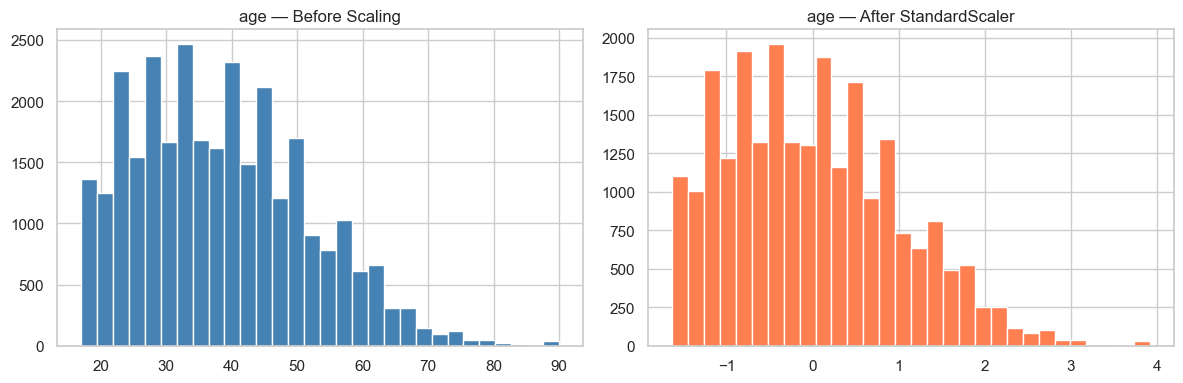

In [27]:
# Before/after scaling comparison
col = 'age'
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_enc[col].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title(f'{col} — Before Scaling')
X_train[col].hist(bins=30, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title(f'{col} — After StandardScaler')
plt.tight_layout()
plt.show()

## 10. Train/Test Split — Save Processed Dataset

In [28]:
OUTPUT_DIR = './dataset_preprocessed/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Combine features + target and save
train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
test_df  = pd.concat([X_test.reset_index(drop=True),  y_test.reset_index(drop=True)],  axis=1)

train_df.to_csv(os.path.join(OUTPUT_DIR, 'train.csv'), index=False)
test_df.to_csv( os.path.join(OUTPUT_DIR, 'test.csv'),  index=False)

# Save feature names
with open(os.path.join(OUTPUT_DIR, 'feature_names.txt'), 'w') as f:
    f.write('\n'.join(X_train.columns.tolist()))

print('=== Saved Files ===')
for fname in os.listdir(OUTPUT_DIR):
    fpath = os.path.join(OUTPUT_DIR, fname)
    print(f'  {fname:30s} {os.path.getsize(fpath)/1024:.1f} KB')

print(f'\ntrain.csv shape : {train_df.shape}')
print(f'test.csv  shape : {test_df.shape}')

=== Saved Files ===
  .gitkeep                       0.2 KB
  feature_names.txt              0.3 KB
  test.csv                       617.7 KB
  train.csv                      2468.9 KB

train.csv shape : (24111, 21)
test.csv  shape : (6028, 21)


In [29]:
# Final preview
print('=== Train Dataset Preview ===')
train_df.head()

=== Train Dataset Preview ===


,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,...,hours_per_week,native_country,age_group,capital_net,has_capital_gain,has_capital_loss,higher_education,work_hours_category,is_married,income
0,1.105582,2,15,-0.045629,0,0,1,4,0,0.0,...,0.200816,38,2,0.0,0,0,1,2,0,0
1,0.649572,1,9,1.131427,5,9,1,4,0,0.0,...,2.090350,38,1,0.0,0,0,1,1,0,0
2,1.333588,2,5,-2.399740,2,6,0,4,1,0.0,...,0.756561,38,2,0.0,0,0,0,2,1,0
3,-0.110445,2,11,-0.437981,4,0,1,4,1,0.0,...,0.089667,38,1,0.0,0,0,0,2,0,0
4,1.181584,3,9,1.131427,2,3,0,4,1,0.0,...,0.978860,38,2,0.0,0,0,1,2,1,1


## Summary

| Step | Action | Result |
|---|---|---|
| 1 | Data loading | 48,842 rows, 15 columns |
| 2 | Inspection | 14 features + 1 target, mixed types |
| 3 | Missing values | ~2% missing in workclass, occupation, native_country → dropped |
| 4 | Duplicates | None found |
| 5 | Outliers | Capped with 3×IQR rule on 5 numerical columns |
| 6 | EDA | Class imbalance ~75/25; education & marital_status are key predictors |
| 7 | Feature engineering | 7 new features added |
| 8 | Encoding | LabelEncoder on 10 categorical columns; target binarised |
| 9 | Scaling | StandardScaler on 6 numerical columns |
| 10 | Split & save | 80/20 stratified split; saved train.csv + test.csv |

---

**Final dataset:**
- Training: ~37,000 samples × 20 features
- Test: ~9,000 samples × 20 features
- Target: `income` (0 = ≤50K, 1 = >50K)